# Getting Started with Image Processing with Python.

## Introduction to Python Imaging Library(PIL)




### Exercise - 1:
Complete all the Task.

1. Read and display the image.

    • Read the image using the Pillow library and display it.

    • You can also use matplotlib to display the image.


In [2]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

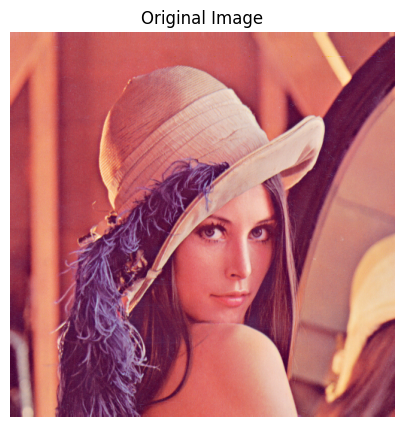

In [4]:
# 1. Read and Display Image

img = Image.open("/content/image.png")
img_array = np.array(img)

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")
plt.show()

2. Display only the top left corner of 100x100 pixels.

    • Extract the top-left corner of the image (100x100 pixels) and display it using NumPy and Array Indexing.


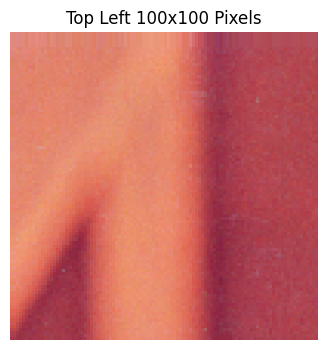

In [5]:
# 2. Display top-left 100x100 pixels

top_left = img_array[0:100, 0:100]

plt.figure(figsize=(4,4))
plt.imshow(top_left)
plt.title("Top Left 100x100 Pixels")
plt.axis("off")
plt.show()

3. Show the three color channels (R, G, B).

    • Separate the image into its three color channels (Red, Green, and Blue) and display them individually, labeling each channel as R, G, and B.{Using NumPy.}


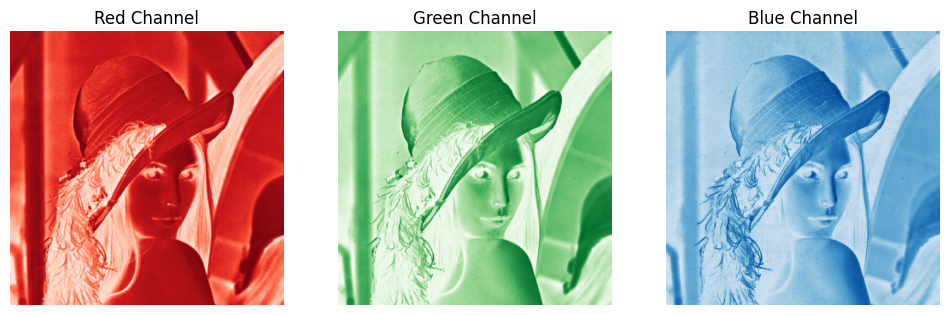

In [7]:
# 3. Separate RGB Channels

R = img_array[:,:,0]
G = img_array[:,:,1]
B = img_array[:,:,2]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(R, cmap='Reds')
plt.title("Red Channel")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(G, cmap='Greens')
plt.title("Green Channel")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(B, cmap='Blues')
plt.title("Blue Channel")
plt.axis("off")

plt.show()



4. Modify the top 100 × 100 pixels to a value of 210 and display the resulting image:

    • Modify the pixel values of the top-left 100 × 100 region to have a value of 210 (which is a light gray color), and then display the modified image.

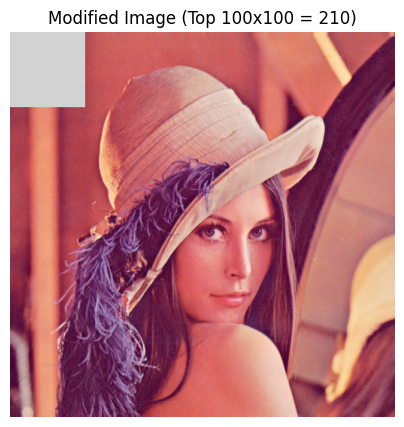

In [6]:

# 4. Modify Top 100x100 Pixels to 210

modified_img = img_array.copy()

modified_img[0:100, 0:100] = 210

plt.figure(figsize=(5,5))
plt.imshow(modified_img)
plt.title("Modified Image (Top 100x100 = 210)")
plt.axis("off")
plt.show()

---

### Exercise - 2:

Complete all the Task.
1. Load and display a grayscale image.

    • Load a grayscale image using the Pillow library.

    • Display the grayscale image using matplotlib.


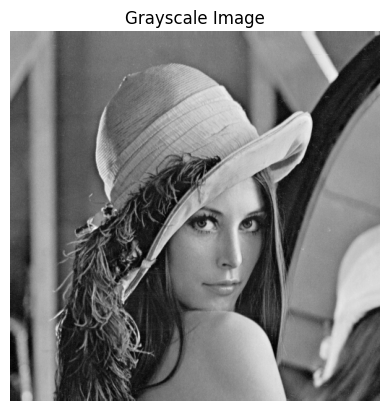

In [9]:
# 1. Load grayscale image

img = Image.open("/content/image.png").convert("L")   # convert to grayscale
img_array = np.array(img)

plt.imshow(img_array, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

2. Extract and display the middle section of the image (150 pixels).

    • Extract a 150 pixel section from the center of the image using NumPy array slicing.

    • Display this cropped image using matplotlib.


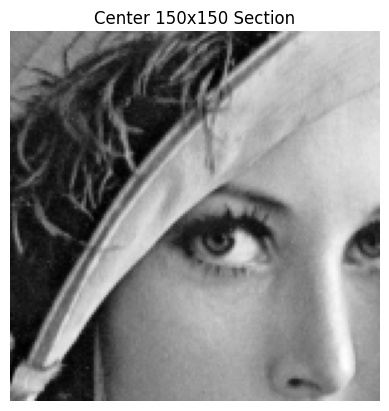

In [10]:
# 2. Extract middle section (150x150 pixels)

h, w = img_array.shape

center_y = h // 2
center_x = w // 2

middle_section = img_array[
    center_y-75:center_y+75,
    center_x-75:center_x+75
]

plt.imshow(middle_section, cmap='gray')
plt.title("Center 150x150 Section")
plt.axis("off")
plt.show()

3. Apply a simple threshold to the image (e.g., set all pixel values below 100 to 0).

    • Apply a threshold to the grayscale image: set all pixel values below 100 to 0, and all values above 100 to 255 (creating a binary image).

    • Display the resulting binary image.


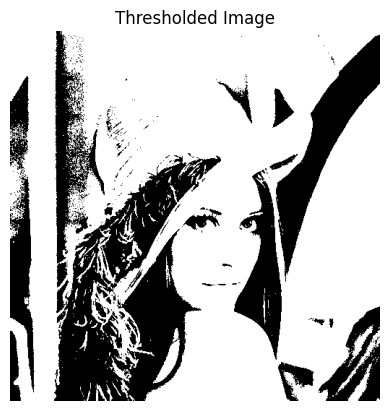

In [16]:
# 3. Apply threshold (Binary Image)

binary_img = img_array.copy()

binary_img[binary_img < 100] = 0
binary_img[binary_img >= 100] = 255

plt.imshow(binary_img, cmap='gray')
plt.title("Thresholded Image")
plt.axis("off")
plt.show()

4. Rotate the image 90 degrees clockwise and display the result.

    • Rotate the image by 90 degrees clockwise using the Pillow rotate method or by manipulating the image array.

    • Display the rotated image using matplotlib.


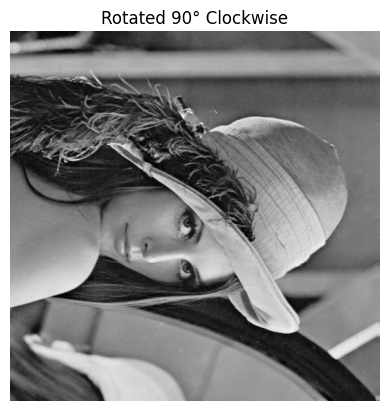

In [15]:
# 4. Rotate image 90° clockwise

rotated = img.rotate(-90)   # negative for clockwise

plt.imshow(rotated, cmap='gray')
plt.title("Rotated 90° Clockwise")
plt.axis("off")
plt.show()

5. Convert the grayscale image to an RGB image.

    • Convert the grayscale image into an RGB image where the grayscale values are replicated across all three channels (R, G, and B).

    • Display the converted RGB image using matplotlib.

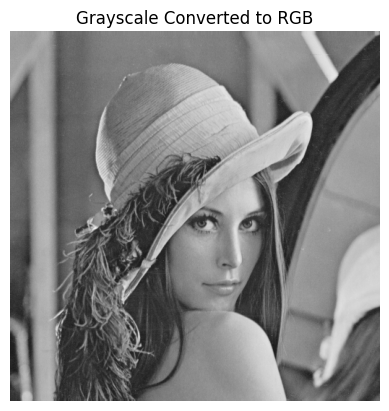

In [14]:
# 5. Convert Grayscale to RGB

rgb_img = np.stack((img_array,)*3, axis=-1)

plt.imshow(rgb_img)
plt.title("Grayscale Converted to RGB")
plt.axis("off")
plt.show()

---

# Image Compression and Decompression using PCA.


In this exercise, build a PCA from scratch using explained variance method for image compression task.
You are expected to compute the necessary matrices from the scratch. Dataset: Use image of your
choice.
1. Load and Prepare Data:
    
    • Fetch an image of you choice.{If colour convert to grayscale}
    
    • Center the dataset - Standaridze the Data.
    
    • Calculate the covaraince matrix of the Standaridze data.

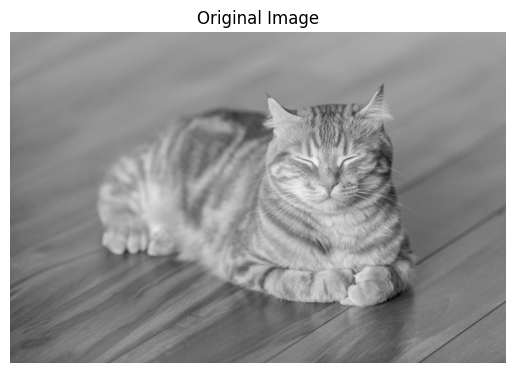

In [18]:

# 1. Load and Prepare Data

# Load image and convert to grayscale
img = Image.open("image.jpg").convert("L")
img_array = np.array(img, dtype=float)

plt.imshow(img_array, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()

# Standardize / Center the data
mean = np.mean(img_array, axis=0)
X_centered = img_array - mean

# Covariance matrix
cov_matrix = np.cov(X_centered, rowvar=False)

2. Eigen Decomposition and Identifying Principal Components:
    
    • Compute Eigen Values and Eigen Vectors.
    
    • Sort the eigenvalues in descending order and choose the top k eigenvectors corresponding to the highest eigenvalues.
    
    • Identify the Principal Components with the help of cumulative Sum plot.


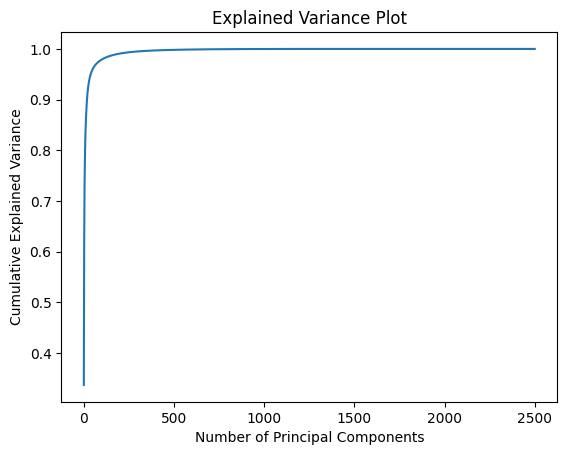

In [20]:
# 2. Eigen Decomposition

# Eigen values and vectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Sort eigenvalues in descending order
sorted_index = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_index]
eigenvectors = eigenvectors[:, sorted_index]

# Explained variance
explained_variance = eigenvalues / np.sum(eigenvalues)

# Cumulative explained variance
cumulative_variance = np.cumsum(explained_variance)

# Plot cumulative variance
plt.plot(cumulative_variance)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance Plot")
plt.show()

3. Reconstruction and Experiment:

    
    • Reconstruction: Transform the original data by multiplying it with the selected eigenvectors(PCs) to obtain a lower-dimensional representation.

    
    • Experiments: Pick Four different combination of principal components with various explained variance value and compare the result.

    
    • Display the Results and Evaluate.

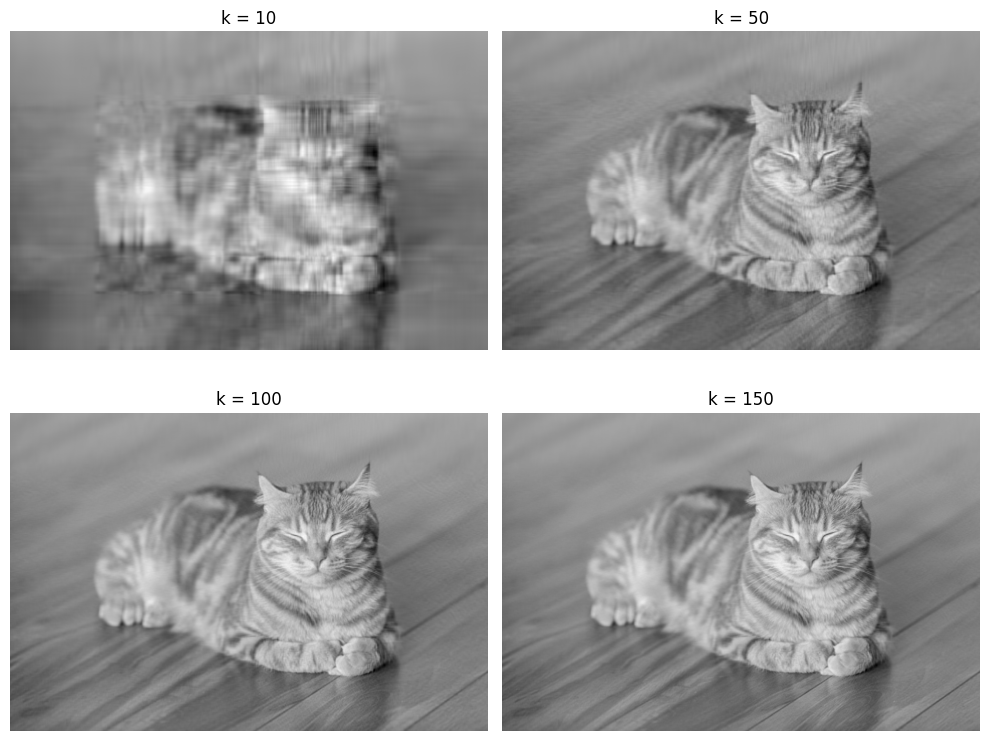

In [24]:
# 3. Reconstruction and Experiments

# choose different k values
k_values = [10, 50, 100, 150]

plt.figure(figsize=(10,8))

for i, k in enumerate(k_values):

    PCs = eigenvectors[:, :k]

    compressed = np.dot(X_centered, PCs)

    reconstructed = np.dot(compressed, PCs.T) + mean
    reconstructed = np.real(reconstructed)

    plt.subplot(2,2,i+1)
    plt.imshow(reconstructed, cmap="gray")
    plt.title(f"k = {k}")
    plt.axis("off")

plt.tight_layout()
plt.show()